## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/diabetes.tsv",sep='\t')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [2]:
df.mean()

AGE     48.518100
SEX      1.468326
BMI     26.375792
BP      94.647014
S1     189.140271
S2     115.439140
S3      49.788462
S4       4.070249
S5       4.641411
S6      91.260181
Y      152.133484
dtype: float64

### Task 2: Plot boxplots for BMI, BP and Y depending on gender

In [3]:
df.var()

AGE     171.846610
SEX       0.249561
BMI      19.519798
BP      191.304401
S1     1197.717241
S2      924.955494
S3      167.293585
S4        1.665261
S5        0.272892
S6      132.165712
Y      5943.331348
dtype: float64

### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

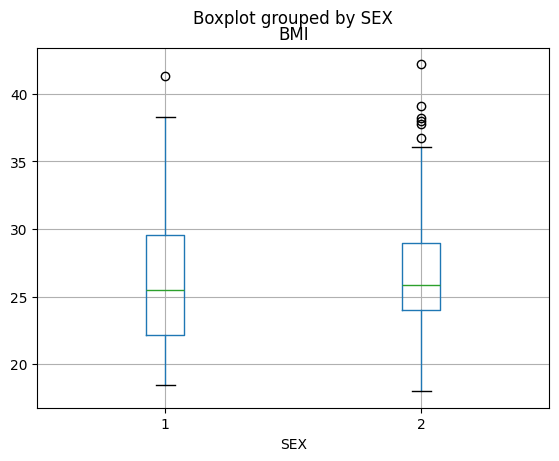

In [4]:
for col in ['BMI']:
    df.boxplot(column=col,by='SEX')
plt.show()    

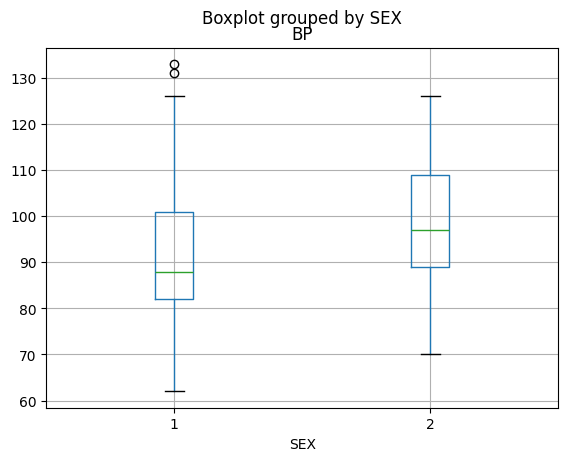

In [5]:
for col in ['BP']:
    df.boxplot(column=col,by='SEX')
plt.show()    

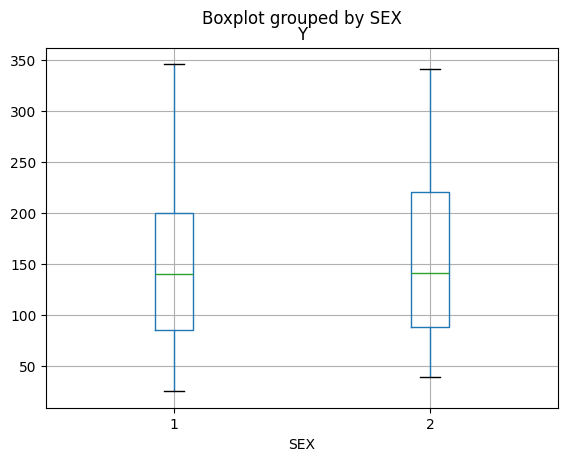

In [6]:
for col in ['Y']:
    df.boxplot(column=col,by='SEX')
plt.show()    

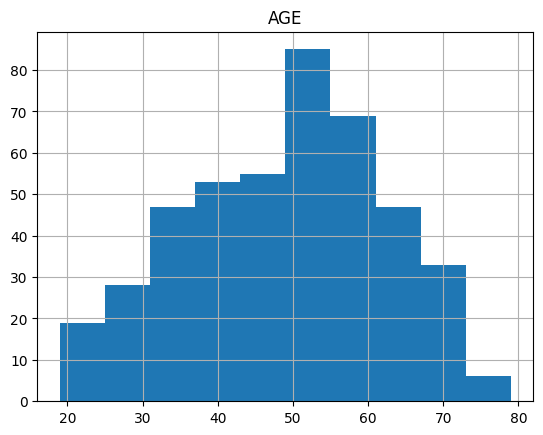

In [7]:
for col in ['AGE']:
    df.hist(column=col)
plt.show()    

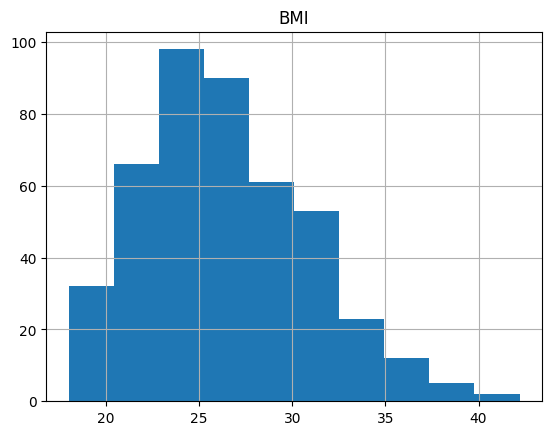

In [8]:
for col in ['BMI']:
    df.hist(column=col)
plt.show()    

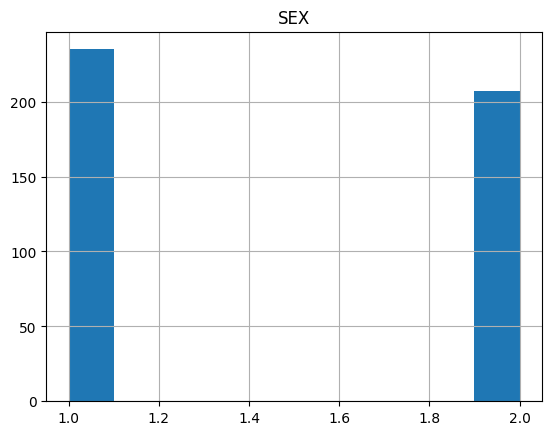

In [9]:
for col in ['SEX']:
    df.hist(column=col)
plt.show()    

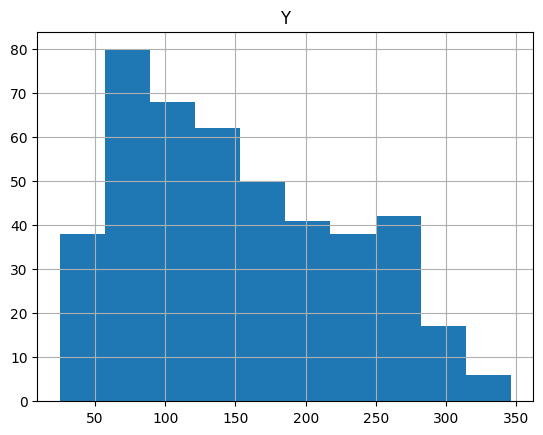

In [10]:
for col in ['Y']:
    df.hist(column=col)
plt.show()    

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

In [11]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


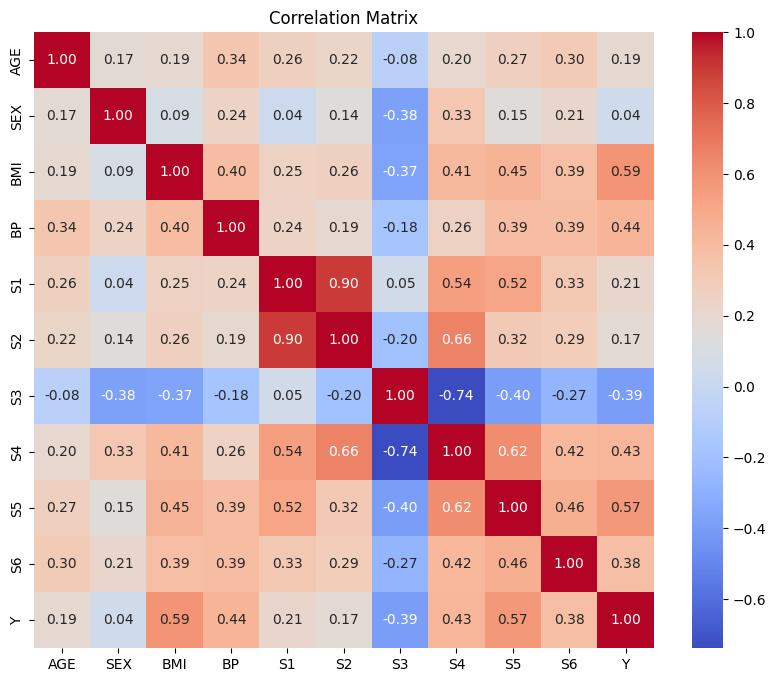

In [12]:

import seaborn as sns

# Compute the correlation matrix
corr = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [13]:
df.corr()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
S1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
S2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
S3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
S4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
S5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
S6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


### Strong Positive Correlations:

S1 and S2 (0.896)
 These two serum variables are highly correlated, indicating that they likely move together and may represent similar physiological information.

BMI and S4 (0.414) and BP and BMI (0.395):
 Higher BMI is associated with both higher S4 levels and higher blood pressure, showing how body composition and fat distribution may influence other health metrics.
 
Y and BMI (0.586): The target variable Y is most strongly correlated with BMI, suggesting that body mass might be a significant predictor of the target outcome.

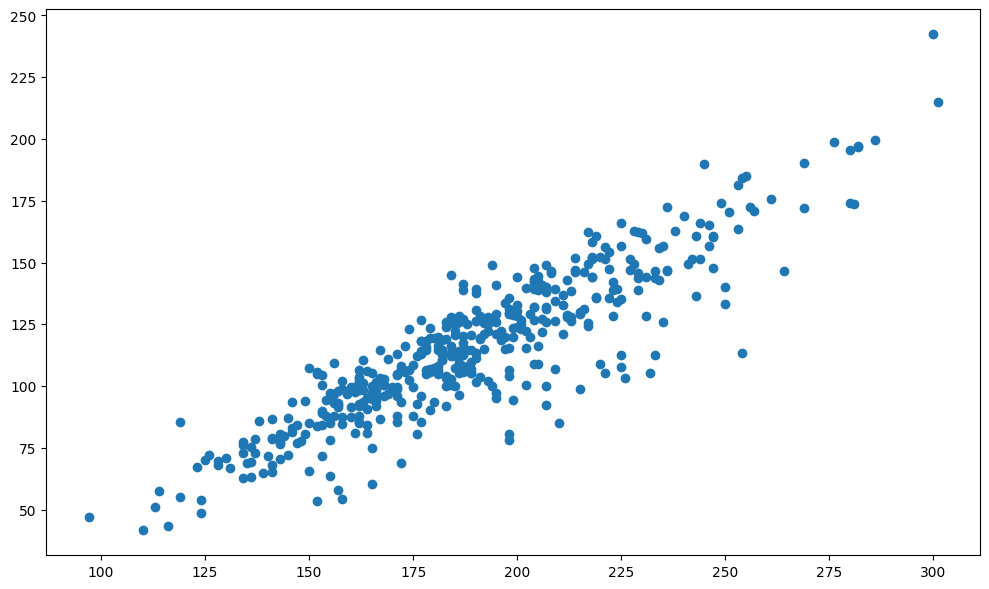

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df['S1'],df['S2'])
plt.tight_layout()
plt.show()

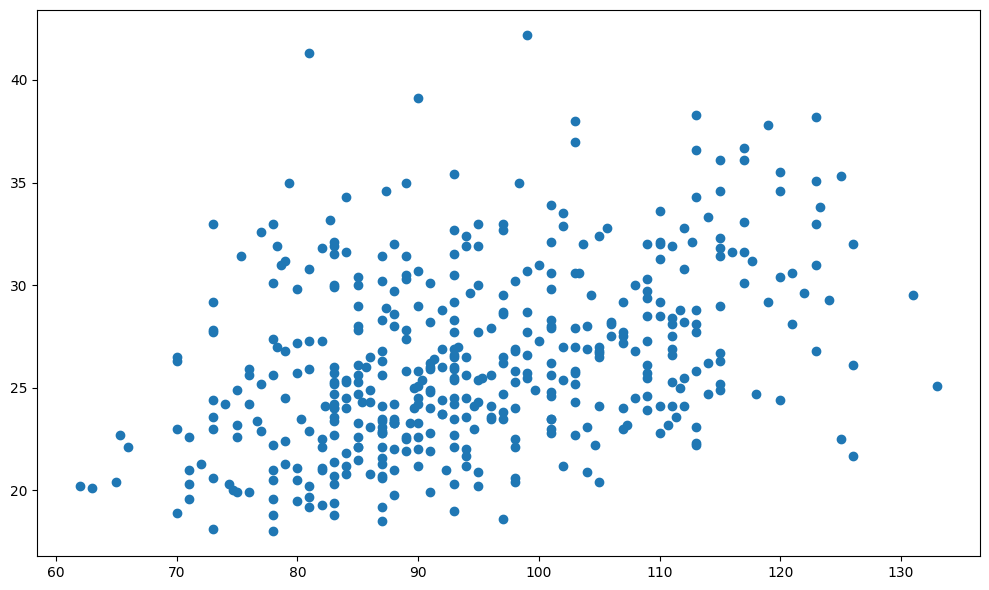

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(df['BP'],df['BMI'])
plt.tight_layout()
plt.show()

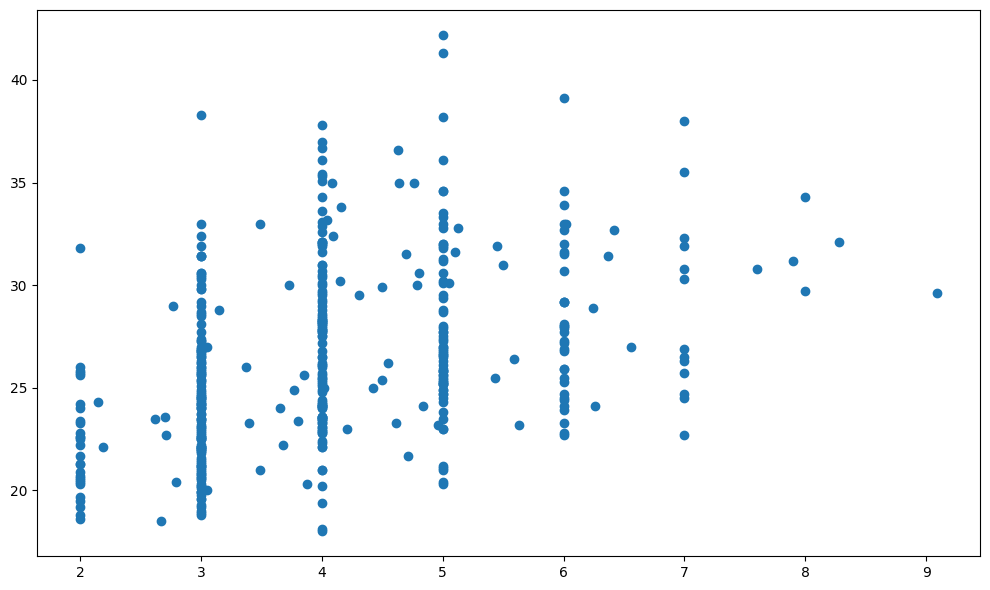

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(df['S4'],df['BMI'])
plt.tight_layout()
plt.show()

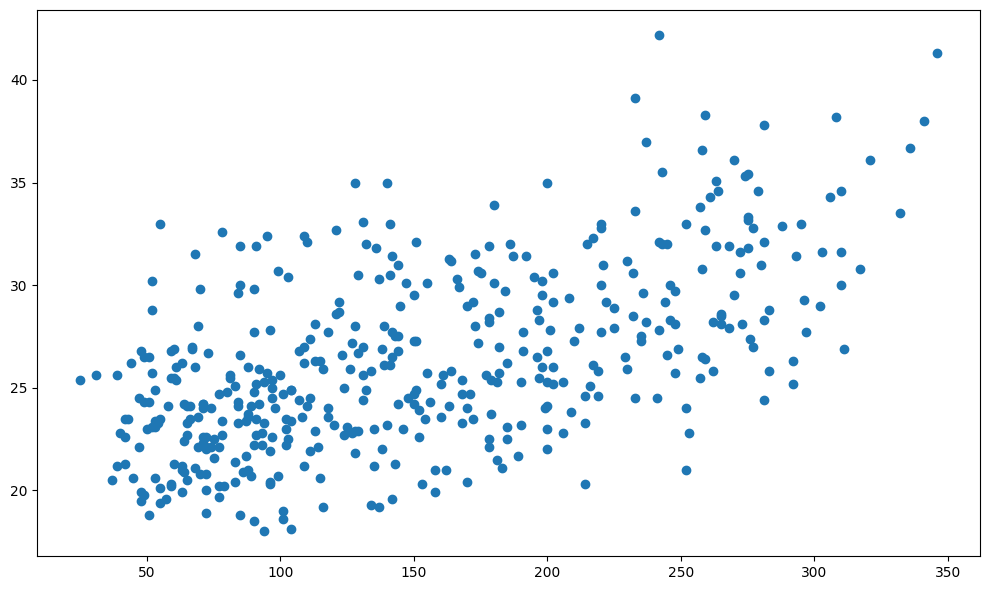

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(df['Y'],df['BMI'])
plt.tight_layout()
plt.show()

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

In [18]:
from scipy.stats import ttest_ind

tval, pval = ttest_ind(df.loc[df['SEX']==1,['Y']], df.loc[df['SEX']==2,['Y']],equal_var=False)
print(f"T-value = {tval[0]:.2f}\nP-value: {pval[0]}")

T-value = -0.90
P-value: 0.3674449793083975


Our p-value indicates that there is no strong evidence that the sex of an individual affects the progression of diabetes.